# Lecture 4a — The questionnaire is the product

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

A robo-adviser asks you five questions, adds up your answers, and puts you in one of five
buckets. Each bucket is a portfolio. Critics call this crude: a human life compressed into a
single integer between 1 and 5.

The criticism is obvious. It is also, as we will measure, **mostly aimed at the wrong thing.**

This notebook asks one question and answers it with numbers:

> **Where does a robo-adviser's advice actually go wrong — in the bucketing, or before it?**

By the end you will have decomposed the total error into three named components, priced each
one in basis points per year, and compared them to the fee the platform charges. The component
everyone criticises turns out to be the smallest of the three, and all three together come to
barely a quarter of the fee.

## The layer

This is the **elicitation** layer — the second of the six in the lecture. It sits between
acquisition (who arrives) and allocation (what they are made to hold). Notebook 4b takes the
allocation layer and asks why the ladder has only five rungs.

---

### How to use this notebook

* Runs end to end in **under 20 seconds**. No internet, no API keys, no data downloads.
* Works identically in **Google Colab, local Anaconda, and the university JupyterHub**.
* Wherever there is real mathematics it sits in a collapsible box — click the triangle to open it. You can pass the subject without opening
  any of them, and you will understand the subject better if you open all of them.
* Exercises at the end are tiered **Core** (do these) and **Stretch** (do these if the
  material came easily).


## 0 · Setup

Only three libraries. Everything below is generated inside this notebook from a fixed seed,
so your numbers will match the ones quoted in the prose exactly.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------------- configuration
SEED       = 20260811   # fixed so every reader sees identical numbers
N_CLIENTS  = 40_000     # size of the synthetic client population
FEE_BP     = 25.0       # advice fee benchmark, basis points per year (0.25% p.a.)

MU_EXCESS  = 0.045      # equity risk premium assumed, p.a.
SIG_EQUITY = 0.16       # equity volatility assumed, p.a.
VAR_EQUITY = SIG_EQUITY ** 2

rng = np.random.default_rng(SEED)

# house plotting style
NAVY, BAND, RED, GREY = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))

print(f"numpy {np.__version__} | pandas {pd.__version__}")
print(f"population {N_CLIENTS:,} clients | seed {SEED}")

numpy 2.4.6 | pandas 3.0.5
population 40,000 clients | seed 20260811


---

## 1 · The instrument

Here is a risk questionnaire of the kind every retail platform uses. Five items, a weighted
sum, and a mapping from the sum to a model portfolio.

Two things are worth noticing in the code below, because both are places where real
implementations go wrong.

**The direction of each item.** Four of the five items point the same way: more experience,
longer horizon, higher stated tolerance and more knowledge all support *more* risk. Income
stability also points that way — a client with a secure salary can absorb a drawdown without
being forced to sell, so stable income **raises** risk capacity. It is easy to write this one
backwards, and a sign error here is invisible in testing: the code runs, returns a number in
the right range, and quietly assigns the wrong portfolio to everyone. Every item's direction
is asserted explicitly below and checked in section 1.1.

**The scale mismatch.** Four items are on a 1–5 scale; horizon is in years, 1 to 20. They
cannot be added until they are on a common scale.

In [2]:
ITEMS = ['experience', 'horizon', 'income_stability', 'risk_tolerance', 'knowledge']

# Weights the product committee signed off on. They must sum to 1.
WEIGHTS = pd.Series({'experience':       0.20,
                     'horizon':          0.20,
                     'income_stability': 0.20,
                     'risk_tolerance':   0.25,
                     'knowledge':        0.15})
assert np.isclose(WEIGHTS.sum(), 1.0), "weights must sum to 1"

# Direction of each item: +1 means a higher answer supports MORE risk.
# income_stability is +1: a secure income raises the capacity to bear a drawdown.
DIRECTION = pd.Series({'experience': +1, 'horizon': +1, 'income_stability': +1,
                       'risk_tolerance': +1, 'knowledge': +1})

# The model-portfolio ladder: equity share for each of the five buckets.
LADDER = np.array([0.20, 0.40, 0.60, 0.75, 0.90])
BUCKET_NAMES = ['Conservative', 'Moderately conservative', 'Moderate',
                'Moderately aggressive', 'Aggressive']


def to_common_scale(responses: pd.DataFrame) -> pd.DataFrame:
    """Put every item on a 1-5 scale and apply its direction."""
    d = responses.copy()
    d['horizon'] = np.interp(d['horizon'], (1, 20), (1, 5))   # years -> 1-5
    for item in ITEMS:                                        # flip if direction is -1
        d[item] = np.where(DIRECTION[item] > 0, d[item], 6 - d[item])
    return d[ITEMS]


def risk_score(responses: pd.DataFrame) -> np.ndarray:
    """Weighted average of the five items. Returns a continuous score in [1, 5]."""
    return (to_common_scale(responses) * WEIGHTS.values).sum(axis=1).to_numpy()

### 1.1 · A direction check that would have caught the sign error

Before trusting any scoring function, assert what it is supposed to do. Take a reference
client, move one item up by a point, and confirm the score moves the way the specification
says it should. Three lines, and it makes an entire class of silent defect impossible.

This is not a nicety. ASIC's **RG 255** requires a licensee providing digital advice to
monitor and test the algorithm that generates it, and to be able to explain why a particular
client received a particular recommendation. A test like this one is the smallest honest
version of that obligation.

In [3]:
def direction_check(verbose=True):
    """Every item must move the score in its declared direction."""
    base = pd.DataFrame({'experience':[3], 'horizon':[10], 'income_stability':[3],
                         'risk_tolerance':[3], 'knowledge':[3]})
    s0, results = risk_score(base)[0], {}
    for item in ITEMS:
        bumped = base.copy()
        bumped[item] += 1                       # one point higher on this item
        moved = risk_score(bumped)[0] - s0
        expected = DIRECTION[item]
        results[item] = (moved, np.sign(moved) == np.sign(expected))
        if verbose:
            flag = 'PASS' if results[item][1] else 'FAIL'
            print(f"  {item:<18} score moves {moved:+.4f}   expected {expected:+d}   [{flag}]")
    assert all(ok for _, ok in results.values()), "an item moves the score the wrong way"
    return results

print("Direction check on the scoring function:")
_ = direction_check()
print("\nAll five items move the score in the declared direction.")

Direction check on the scoring function:
  experience         score moves +0.2000   expected +1   [PASS]
  horizon            score moves +0.0421   expected +1   [PASS]
  income_stability   score moves +0.2000   expected +1   [PASS]
  risk_tolerance     score moves +0.2500   expected +1   [PASS]
  knowledge          score moves +0.1500   expected +1   [PASS]

All five items move the score in the declared direction.


---

## 2 · A synthetic client population

To ask whether the questionnaire *works*, we need something to compare it against: each
client's true optimal equity weight. In the field this is unobservable, which is precisely
why questionnaire error is so rarely measured. In a simulation we can construct it, and then
watch how much of it the questionnaire recovers.

Every parameter below is disclosed and adjustable. The results in this notebook are only as
good as these assumptions, and section 7 asks you to change them and see what survives.

<details>
<summary><b>The generative model (click to open)</b></summary>

A client with constant relative risk aversion $\gamma$ facing one risky asset with excess
return $\mu_e$ and volatility $\sigma$ holds an optimal risky-asset weight

$$w^{*} = \frac{\mu_e}{\gamma \sigma^{2}}$$

We draw $\log \gamma \sim \mathcal{N}(\log \bar\gamma,\, 0.42^{2})$, with $\bar\gamma$ set so
the median client's optimal equity weight is 55%. This gives a population whose optimal equity
weights run from roughly 30% at the 10th percentile to 95% at the 90th — about the spread a
retail platform actually sees.

The client's **risk posture** $z$ is the standardised negative of $\log\gamma$, so a high $z$
means a bold client. Each questionnaire item is a noisy, coarse reading of $z$:

$$r_{ij} = \text{round}\!\left(3 + a_j z_i + s_j \varepsilon_{ij}\right), \qquad
\varepsilon_{ij}\sim\mathcal{N}(0,1)$$

where $a_j$ is the item's loading on true risk posture and $s_j$ its idiosyncratic noise. The
rounding matters: a five-point scale destroys information before any weighting happens. Items
differ in quality — stated risk tolerance loads most heavily ($a=0.85$) and income stability
least ($a=0.45$), which is roughly what the psychometric literature finds.
</details>

In [4]:
# Item quality: loading on true risk posture, and idiosyncratic noise.
LOADING = pd.Series({'experience':0.55, 'horizon':0.70, 'income_stability':0.45,
                     'risk_tolerance':0.85, 'knowledge':0.50})
NOISE   = pd.Series({'experience':0.63, 'horizon':0.53, 'income_stability':0.70,
                     'risk_tolerance':0.42, 'knowledge':0.67})

# ---- true optimal equity weight for each client -------------------------------
gamma_median = MU_EXCESS / (0.55 * VAR_EQUITY)          # gamma giving w* = 55%
log_gamma    = np.log(gamma_median) + 0.42 * rng.normal(size=N_CLIENTS)
gamma        = np.clip(np.exp(log_gamma), 1.9, 20.0)    # risk aversion
w_true       = np.clip(MU_EXCESS / (gamma * VAR_EQUITY), 0.05, 0.95)
z            = (np.log(gamma_median) - log_gamma) / 0.42   # risk posture, higher = bolder


def administer(z, rng):
    """Sit the whole population down and have them fill in the questionnaire once."""
    out = {}
    for item in ITEMS:
        latent = LOADING[item] * z + NOISE[item] * rng.normal(size=len(z))
        if item == 'horizon':
            out[item] = np.clip(np.round(10 + 4.5 * latent), 1, 20)
        else:
            out[item] = np.clip(np.round(3 + latent), 1, 5)
    return pd.DataFrame(out)


sitting_1 = administer(z, rng)
score_1   = risk_score(sitting_1)

print(f"True optimal equity weight   mean {w_true.mean():.1%}   "
      f"p10 {np.quantile(w_true,0.1):.0%}   p90 {np.quantile(w_true,0.9):.0%}")
print(f"Questionnaire score          mean {score_1.mean():.2f}   sd {score_1.std():.2f}   "
      f"range {score_1.min():.2f} to {score_1.max():.2f}")
print(f"Correlation of score with true risk posture: {np.corrcoef(score_1, z)[0,1]:.3f}")

True optimal equity weight   mean 57.5%   p10 32%   p90 93%
Questionnaire score          mean 2.98   sd 0.67   range 1.00 to 5.00
Correlation of score with true risk posture: 0.908


---

## 3 · Does the score ever reach the ends?

The scoring function returns a number between 1 and 5. The obvious way to turn that into a
bucket is to round it. Almost every teaching implementation does exactly this, and so do a
number of production ones.

Rounding is a trap, and the reason is the central limit theorem. A weighted average of five
items, each roughly independent given the client, has **far less dispersion than any one
item**. The score clusters near 3 even when the underlying clients are spread widely. Rounding
that clustered score gives you five nominal buckets of which two are nearly empty.

The alternative is to place the cut points where the population actually is: split the score
distribution at its quintiles, so each bucket gets a fifth of clients by construction.

In [5]:
# Rule A: round the score to the nearest integer.
bucket_round = np.clip(np.round(score_1), 1, 5).astype(int)

# Rule B: cut the score distribution at its quintiles.
CUTS = np.quantile(score_1, [0.2, 0.4, 0.6, 0.8])
bucket_calib = np.digitize(score_1, CUTS) + 1

occupancy = pd.DataFrame({
    'Round the score': pd.Series(bucket_round).value_counts(normalize=True).sort_index() * 100,
    'Calibrated cuts': pd.Series(bucket_calib).value_counts(normalize=True).sort_index() * 100,
}).reindex(range(1, 6)).fillna(0.0)
occupancy.index = [f"{i}. {n}" for i, n in zip(range(1, 6), BUCKET_NAMES)]

print("Share of clients landing in each bucket (%)\n")
print(occupancy.round(1).to_string())
print(f"\nUnder rounding, the two extreme buckets together hold "
      f"{occupancy['Round the score'].iloc[[0,-1]].sum():.1f}% of clients.")
print(f"Cut points used by the calibrated rule: {np.round(CUTS, 3)}")

Share of clients landing in each bucket (%)

                            Round the score  Calibrated cuts
1. Conservative                         1.2             19.7
2. Moderately conservative             23.3             20.3
3. Moderate                            53.3             19.6
4. Moderately aggressive               21.0             20.2
5. Aggressive                           1.1             20.2

Under rounding, the two extreme buckets together hold 2.3% of clients.
Cut points used by the calibrated rule: [2.403 2.805 3.137 3.547]


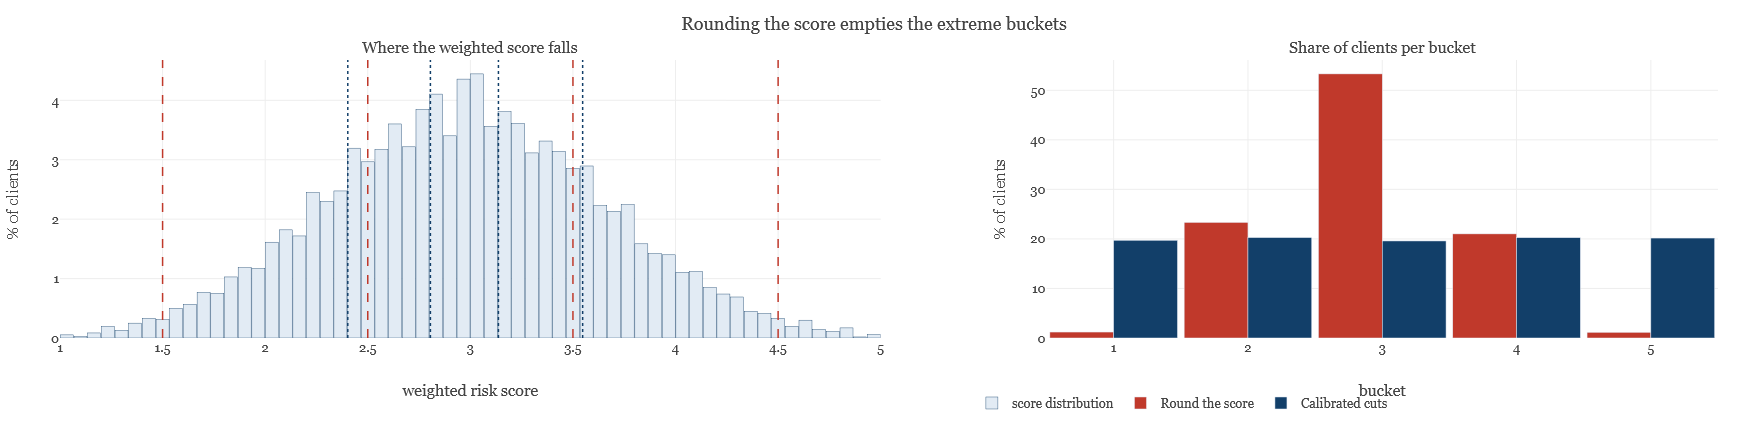

In [6]:
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    'Where the weighted score falls', 'Share of clients per bucket'),
    column_widths=[0.55, 0.45])

counts, edges = np.histogram(score_1, bins=60)
centres = (edges[:-1] + edges[1:]) / 2
fig.add_trace(go.Bar(x=centres, y=counts / counts.sum() * 100, marker_color=BAND,
                     marker_line_color=NAVY, marker_line_width=0.4,
                     name='score distribution', hovertemplate='score %{x:.2f}<br>%{y:.2f}% of clients<extra></extra>'),
              row=1, col=1)
for c in CUTS:
    fig.add_vline(x=c, line=dict(color=NAVY, width=1.5, dash='dot'), row=1, col=1)
for c in [1.5, 2.5, 3.5, 4.5]:
    fig.add_vline(x=c, line=dict(color=RED, width=1.5, dash='dash'), row=1, col=1)

fig.add_trace(go.Bar(x=list(range(1, 6)), y=occupancy['Round the score'], name='Round the score',
                     marker_color=RED, hovertemplate='bucket %{x}<br>%{y:.1f}%<extra></extra>'), row=1, col=2)
fig.add_trace(go.Bar(x=list(range(1, 6)), y=occupancy['Calibrated cuts'], name='Calibrated cuts',
                     marker_color=NAVY, hovertemplate='bucket %{x}<br>%{y:.1f}%<extra></extra>'), row=1, col=2)

fig.update_xaxes(title_text='weighted risk score', row=1, col=1)
fig.update_xaxes(title_text='bucket', tickmode='array', tickvals=list(range(1, 6)), row=1, col=2)
fig.update_yaxes(title_text='% of clients', row=1, col=1)
fig.update_yaxes(title_text='% of clients', row=1, col=2)
fig.update_layout(template=TEMPLATE, height=430, bargap=0.05, barmode='group',
                  title_text='Rounding the score empties the extreme buckets',
                  legend=dict(orientation='h', y=-0.18, x=0.55))
fig.show()

**Read the left panel carefully.** The red dashed lines are where rounding cuts; the navy
dotted lines are the calibrated quintile cuts. The red lines at 1.5 and 4.5 sit far out in the
tails of a distribution whose standard deviation is about 0.7. Almost nobody reaches them.

So the platform advertises a five-point risk spectrum and operates a three-point one. The
"Aggressive" portfolio exists in the marketing material and is issued to about one client in a
hundred — including, note, clients who genuinely should hold it. This is not a rounding
detail; it is a systematic conservatism baked into the arithmetic, and no one in the business
would ever see it unless they plotted this exact chart.

We use the calibrated rule from here on.

---

## 4 · Would the same client get the same portfolio twice?

A questionnaire is a measuring instrument. The first thing you ask of any instrument is
whether it gives the same reading twice on the same object.

Nothing about the client changes between the two sittings below. Same person, same wealth,
same true risk aversion. Only the noise in how they answer on the day is redrawn — they are
slightly more or less optimistic, they read a question differently, they round their horizon
to 10 years instead of 12.

In [7]:
sitting_2 = administer(z, rng)          # same clients, same day, second attempt
score_2    = risk_score(sitting_2)
bucket_2   = np.digitize(score_2, CUTS) + 1

reliability = np.corrcoef(score_1, score_2)[0, 1]
agreement   = (bucket_calib == bucket_2).mean()
moved_two   = (np.abs(bucket_calib - bucket_2) >= 2).mean()

# What if just one answer changes by a single point?
nudged = sitting_1.copy()
nudged['risk_tolerance'] = np.clip(nudged['risk_tolerance'] + rng.choice([-1, 1], N_CLIENTS), 1, 5)
flip_one = ((np.digitize(risk_score(nudged), CUTS) + 1) != bucket_calib).mean()

print(f"Score reliability (correlation across sittings) : {reliability:.3f}")
print(f"Clients placed in the SAME bucket twice         : {agreement:.1%}")
print(f"Clients who moved two or more buckets           : {moved_two:.1%}")
print(f"Bucket changes when ONE answer moves by 1 point : {flip_one:.1%}")
print(f"\nEquity-weight swing when a bucket changes by one rung: "
      f"{np.diff(LADDER).mean():.0%} of the portfolio")

Score reliability (correlation across sittings) : 0.823
Clients placed in the SAME bucket twice         : 48.7%
Clients who moved two or more buckets           : 11.0%
Bucket changes when ONE answer moves by 1 point : 47.9%

Equity-weight swing when a bucket changes by one rung: 18% of the portfolio


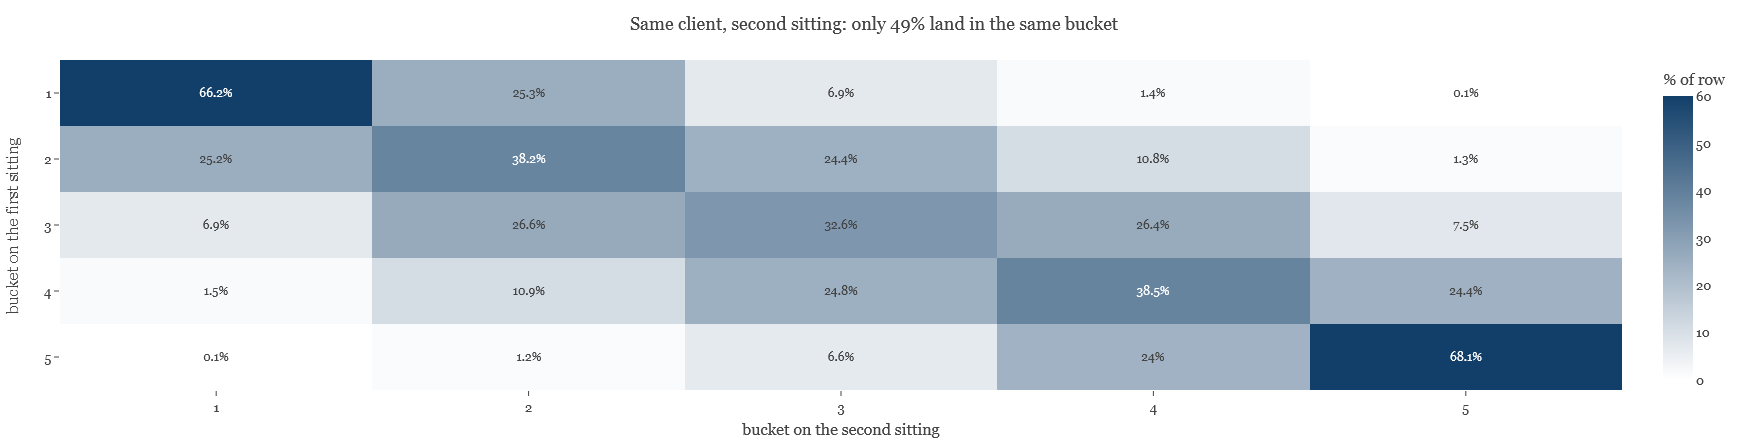

In [8]:
conf = pd.crosstab(bucket_calib, bucket_2, normalize='index') * 100
conf = conf.reindex(index=range(1, 6), columns=range(1, 6)).fillna(0)

fig = go.Figure(go.Heatmap(
    z=conf.values, x=[f"{i}" for i in range(1, 6)], y=[f"{i}" for i in range(1, 6)],
    colorscale=[[0, 'white'], [1, NAVY]], zmin=0, zmax=60,
    text=np.round(conf.values, 1), texttemplate='%{text}%',
    textfont=dict(size=12), colorbar=dict(title='% of row'),
    hovertemplate='first sitting %{y} -> second sitting %{x}<br>%{z:.1f}% of that group<extra></extra>'))
fig.update_layout(template=TEMPLATE, height=440,
                  title_text=f'Same client, second sitting: only {agreement:.0%} land in the same bucket',
                  xaxis_title='bucket on the second sitting',
                  yaxis_title='bucket on the first sitting',
                  yaxis=dict(autorange='reversed'))
fig.show()

The diagonal is the instrument's memory. Everything off it is a client who would have been
sold a different portfolio had they filled in the form on a different afternoon.

Notice the asymmetry at the corners: clients in bucket 1 or 5 on the first sitting are the
*least* likely to stay there. That is regression to the mean, and it means the extreme
portfolios are not merely rare — the clients assigned to them are disproportionately there by
accident.

And the single-item result is the one to remember. One item carries a weight of 0.25; a bucket
is about 0.4 score-points wide. So moving one answer by one point moves a client roughly
**60% of a bucket width**. That is arithmetic, not noise: any questionnaire whose heaviest item
weight is comparable to its bucket width will behave this way.

<details>
<summary><b>Why one item can move a bucket (click to open)</b></summary>

With $k$ equal-occupancy buckets over a score with standard deviation $\sigma_s$, the typical
bucket width near the centre is roughly

$$\Delta \approx \frac{\sigma_s}{k \cdot \phi(0)} \approx \frac{2.5\,\sigma_s}{k}$$

Here $\sigma_s \approx 0.70$ and $k=5$, giving $\Delta \approx 0.35$. A one-point change on an
item of weight $w_j$ shifts the score by exactly $w_j$. For the heaviest item $w_j = 0.25$,
which is $0.25/0.35 \approx 71\%$ of a bucket width.

The design implication is direct: **the largest item weight should be small relative to the
bucket width**, or equivalently $\max_j w_j \ll 2.5\sigma_s / k$. Adding more buckets makes this
worse, not better — which is one reason platforms do not offer fifty of them.
</details>

---

## 5 · What does the bucketing actually cost?

We now price the errors. The natural unit is the **certainty-equivalent loss**: how much annual
return a client would give up to avoid holding the wrong portfolio. Expressing it in basis
points makes it directly comparable to the fee.

<details>
<summary><b>The certainty-equivalent loss (click to open)</b></summary>

A mean-variance investor holding equity weight $w$ has certainty-equivalent return

$$\text{CE}(w) = w\mu_e - \tfrac{\gamma}{2}w^{2}\sigma^{2}$$

maximised at $w^{*} = \mu_e/(\gamma\sigma^{2})$. Substituting and simplifying, holding $w$
instead of $w^{*}$ costs

$$\text{CE}(w^{*}) - \text{CE}(w) = \frac{\gamma\sigma^{2}}{2}\,(w - w^{*})^{2}$$

Three features matter. The loss is **quadratic**, so small misallocations are very cheap and
large ones are not. It scales with $\gamma$, so cautious clients are hurt more by a given error
than bold ones. And it depends only on the *distance* from optimal, not the direction — being
10 points too aggressive costs the same as 10 points too conservative.
</details>

In [9]:
def ce_loss_bp(delta_w, gamma=gamma):
    """Certainty-equivalent loss in basis points p.a. from holding the wrong equity weight."""
    return 1e4 * (gamma / 2) * VAR_EQUITY * delta_w ** 2


# The best a perfectly calibrated continuous mapping could do with this score.
slope, intercept = np.polyfit(score_1, w_true, 1)
w_from_score = np.clip(slope * score_1 + intercept, 0.05, 0.95)

# The best possible placement of five levels, given the same score (Lloyd quantiser).
idx_opt   = np.digitize(w_from_score, np.quantile(w_from_score, [0.2, 0.4, 0.6, 0.8]))
opt_rungs = np.array([w_from_score[idx_opt == i].mean() for i in range(5)])
w_optimal_ladder = opt_rungs[idx_opt]

w_industry_ladder = LADDER[bucket_calib - 1]     # what the client actually gets

budget = pd.DataFrame({
    'RMS error in equity weight': [
        np.sqrt(np.mean((w_optimal_ladder - w_from_score) ** 2)),
        np.sqrt(np.mean((w_industry_ladder - w_optimal_ladder) ** 2)),
        np.sqrt(np.mean((w_from_score - w_true) ** 2)),
        np.sqrt(np.mean((w_industry_ladder - w_true) ** 2))],
    'Cost (bp p.a.)': [
        ce_loss_bp(w_optimal_ladder - w_from_score).mean(),
        ce_loss_bp(w_industry_ladder - w_optimal_ladder).mean(),
        ce_loss_bp(w_from_score - w_true).mean(),
        ce_loss_bp(w_industry_ladder - w_true).mean()]},
    index=['1. Quantisation (5 buckets, best placement)',
           '2. Ladder placement (industry rungs vs best)',
           '3. Measurement (questionnaire misreads client)',
           'TOTAL (what the client is handed vs truth)'])

print(budget.round({'RMS error in equity weight': 3, 'Cost (bp p.a.)': 2}).to_string())
print(f"\nAdvice fee benchmark: {FEE_BP:.0f} bp p.a.")
print(f"\nIndustry rungs : {np.round(LADDER, 2)}")
print(f"Best placement : {np.round(opt_rungs, 2)}")

                                                RMS error in equity weight  Cost (bp p.a.)
1. Quantisation (5 buckets, best placement)                          0.052            1.56
2. Ladder placement (industry rungs vs best)                         0.081            3.41
3. Measurement (questionnaire misreads client)                       0.092            3.52
TOTAL (what the client is handed vs truth)                           0.125            7.07

Advice fee benchmark: 25 bp p.a.

Industry rungs : [0.2  0.4  0.6  0.75 0.9 ]
Best placement : [0.32 0.48 0.57 0.67 0.83]


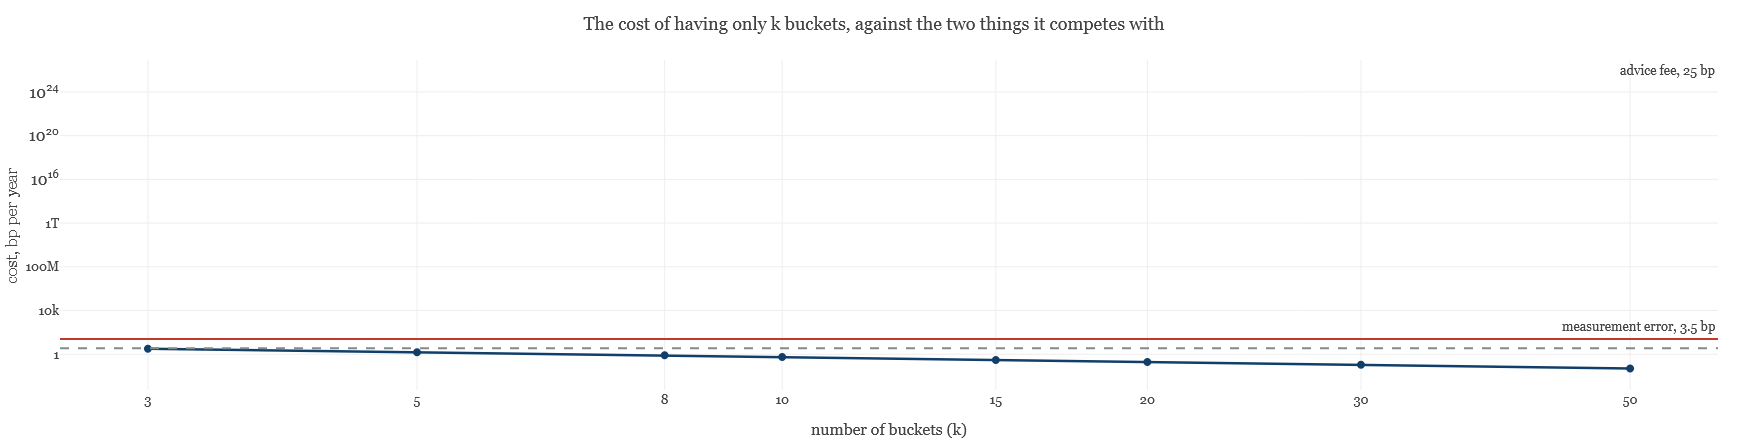

In [10]:
ks = [3, 5, 8, 10, 15, 20, 30, 50]
quant_cost = []
for k in ks:
    edges = np.quantile(w_from_score, np.linspace(0, 1, k + 1))[1:-1]
    ii = np.digitize(w_from_score, edges)
    levels = np.array([w_from_score[ii == i].mean() for i in range(k)])
    quant_cost.append(ce_loss_bp(levels[ii] - w_from_score).mean())

measurement = budget.loc['3. Measurement (questionnaire misreads client)', 'Cost (bp p.a.)']

fig = go.Figure()
fig.add_trace(go.Scatter(x=ks, y=quant_cost, mode='lines+markers', name='cost of using k buckets',
                         line=dict(color=NAVY, width=2.5), marker=dict(size=8),
                         hovertemplate='%{x} buckets<br>%{y:.2f} bp p.a.<extra></extra>'))
fig.add_hline(y=FEE_BP, line=dict(color=RED, width=2),
              annotation_text=f'advice fee, {FEE_BP:.0f} bp', annotation_position='top right')
fig.add_hline(y=measurement, line=dict(color=GREY, width=2, dash='dash'),
              annotation_text=f'measurement error, {measurement:.1f} bp', annotation_position='bottom right')
fig.update_layout(template=TEMPLATE, height=440,
                  title_text='The cost of having only k buckets, against the two things it competes with',
                  xaxis_title='number of buckets (k)', yaxis_title='cost, bp per year',
                  xaxis_type='log', yaxis_type='log',
                  xaxis=dict(tickmode='array', tickvals=ks, ticktext=[str(k) for k in ks]))
fig.show()

Both reference lines sit **above** the quantisation curve across its entire range. Going from
five buckets to fifty buys back well under a basis point, while the questionnaire's inability
to read the client correctly costs several, and the fee costs an order of magnitude more than
either.

---

## 6 · The error budget

Putting the three components side by side against the fee is the single most useful chart in
this notebook.

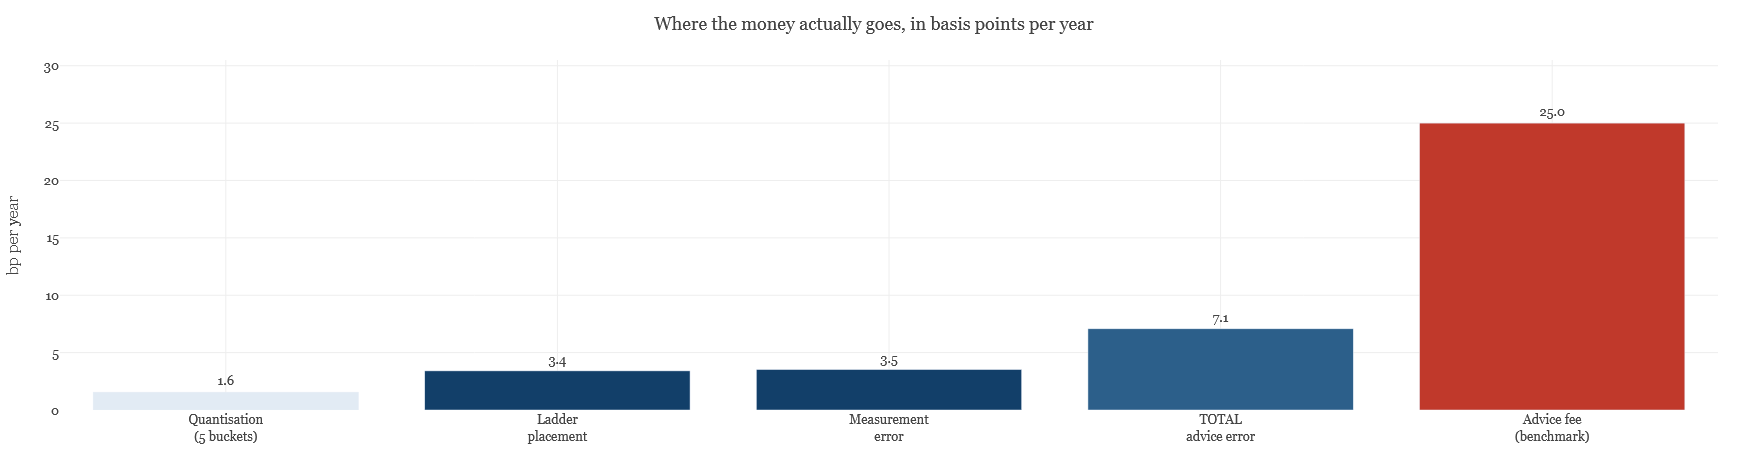

Measurement error is 2.3x the cost of the five-bucket discretisation.
Total advice error is 28% of the fee.


In [11]:
labels = ['Quantisation\n(5 buckets)', 'Ladder\nplacement', 'Measurement\nerror',
          'TOTAL\nadvice error', 'Advice fee\n(benchmark)']
vals = list(budget['Cost (bp p.a.)'].values[:3]) + [budget['Cost (bp p.a.)'].values[3], FEE_BP]
cols = [BAND, NAVY, NAVY, '#2C5F8A', RED]

fig = go.Figure(go.Bar(x=[l.replace('\n', '<br>') for l in labels], y=vals, marker_color=cols,
                       text=[f'{v:.1f}' for v in vals], textposition='outside',
                       hovertemplate='%{x}<br>%{y:.2f} bp p.a.<extra></extra>'))
fig.update_layout(template=TEMPLATE, height=460, showlegend=False,
                  title_text='Where the money actually goes, in basis points per year',
                  yaxis_title='bp per year', yaxis_range=[0, max(vals) * 1.22])
fig.show()

ratio = budget['Cost (bp p.a.)'].iloc[2] / budget['Cost (bp p.a.)'].iloc[0]
print(f"Measurement error is {ratio:.1f}x the cost of the five-bucket discretisation.")
print(f"Total advice error is {budget['Cost (bp p.a.)'].iloc[3]/FEE_BP:.0%} of the fee.")

## 7 · What this means for design

Three conclusions, each of which contradicts something a reasonable person would have guessed
before running the code.

**The discretisation is nearly free.** Compressing a client into one of five buckets costs
about a basis point and a half a year. The criticism that opens this notebook — a human life
reduced to an integer — is aesthetically correct and financially trivial. A platform that spent
a year building per-client continuous optimisation would recover less than two basis points,
and notebook 4b shows that even that estimate is generous.

**Where you put the rungs matters more than how many you have.** The industry ladder spreads
clients from 20% to 90% equity; the population's own dispersion is narrower than that. Simply
repositioning five rungs, without adding a sixth, recovers about twice what the discretisation
costs. Ladder placement is a calibration exercise that almost nobody runs.

**The questionnaire is the weak link, and it is the one nobody audits.** Measurement error is
the largest single component — though only narrowly ahead of ladder placement, and the honest
summary is that both dwarf the discretisation. It is also the hardest to see, because detecting
it requires knowing the truth you are trying to measure. A platform can validate its optimiser against a
benchmark and its rebalancer against a tolerance band. Validating the questionnaire requires
either a test–retest study or an outcome study, and these are rare.

This is why the lecture's thesis holds that a robo-adviser is a preference-elicitation system
with an optimiser bolted on. The elicitation layer is where the error lives. It is also the
layer that receives the least engineering attention, precisely because it looks like a form
rather than a model.

**What this notebook does not show.** All of it rests on a generative model we wrote ourselves.
The specific basis-point figures are properties of the assumptions in section 2, not measured
facts about any real platform. What is robust is the *ordering* and the *mechanism*: quadratic
loss makes small allocation errors cheap, so any error source that shifts a client a long way
will dominate any error source that shifts them a short way. The exercises below ask you to
find the assumptions under which the ordering flips.

---

## Exercises

### Core

**C1 · Break the direction check.** Change `DIRECTION['income_stability']` to `-1` and re-run
sections 1.1 through 6. The assertion in `direction_check()` will fire. Comment the assertion
out, run the rest anyway, and report the total advice error in basis points. How large is the
sign error compared with everything else in the budget? Would a client notice? Would an
auditor, without this notebook?

**C2 · Fix the ladder.** Replace `LADDER` with `opt_rungs` from section 5 and re-run the error
budget. How much of the total do you recover? Write two sentences you could put in a product
committee paper justifying the change.

**C3 · Weight concentration.** Set all five weights to 0.20 and re-run section 4. Does the
single-item flip rate go up or down, and why? Now set `risk_tolerance` to 0.50 and the others
to 0.125 each. State the general relationship between the largest item weight and instrument
stability.

**C4 · Rounding versus calibration.** Some platforms use a fixed published score-to-bucket
table rather than population quantiles, because the table can go in the disclosure document
and quantiles move as the client base changes. Argue both sides in a short paragraph. Which
would you choose, and what would you monitor?

### Stretch

**S1 · Find the flip.** Section 7 claims measurement error dominates quantisation. Find a
combination of `NOISE` and `LADDER` under which quantisation dominates instead. Is that
combination plausible for a real platform? What does your answer imply about how much the
conclusion depends on the simulation?

**S2 · Buy a better questionnaire.** Suppose adding a sixth item with loading 0.80 and noise
0.40 costs the client 3 bp a year in additional onboarding friction and abandonment. Extend
`administer()` and `WEIGHTS`, measure the reduction in measurement error, and decide whether
the item pays for itself.

**S3 · Non-linear horizon.** `to_common_scale()` maps 1–20 years linearly onto 1–5. But the
difference between a 1-year and a 5-year horizon is far more consequential than between 16 and
20 years. Implement a concave mapping (a log or square-root transform), re-run the budget, and
report which component moves.

**S4 · Who bears the error?** The certainty-equivalent loss scales with $\gamma$. Group clients
into quintiles of true risk aversion and report the total advice error for each. Is the burden
of a badly calibrated ladder spread evenly, and what does your answer suggest about which
clients a platform should worry about first?

---

## Appendix · Reference

**Notation.** $z$ risk posture (standardised, higher = bolder) · $\gamma$ coefficient of risk
aversion · $w^{*}$ true optimal equity weight · $\hat{w}$ equity weight implied by the score ·
$k$ number of buckets.

**Parameters used.** Equity excess return 4.5% p.a., equity volatility 16% p.a., population
median optimal equity weight 55%, log-risk-aversion dispersion 0.42, fee benchmark 25 bp p.a.
Item loadings and noise are set in section 2 and are the assumptions most worth challenging.

**Where this goes next.** Notebook 4b takes the ladder as given and asks the allocation
question: why five rungs rather than five hundred, and what is the optimiser behind them
actually doing. The answer there turns out to make the numbers in this notebook look even
smaller.

**Regulatory hooks.** ASIC RG 255 (digital advice to retail clients) requires algorithm
monitoring and the ability to explain an individual recommendation; ASIC REP 798 (October 2024)
surveys AI governance across licensees. The direction check in section 1.1 and the test–retest
study in section 4 are the smallest honest artefacts either obligation would accept.